# GNN for edge classification to link the tracksters

Here, we will create an Edge classification graph that will link the tracksters belonging to the same particle. We will have the following properties:
1. Nodes: Tracksters
2. Node features: Trackster features
3. True label: From Associations tree
4. Edge features: .....

## Opening the root file

In [1]:
import uproot
import awkward as ak
import numpy as np

file=uproot.open("flat_tree_for_Neutron.root")

tracksters=file["ticlDumper/CLUE3DHighTree"].arrays(library="ak")
simtracksters=file["ticlDumper/SimTrackstersTree"].arrays(library="ak")
associations=file["ticlDumper/associations"].arrays(library="ak")

In [2]:
tracksters

<Array [{run_: 1, ...}, ..., {run_: 1, ...}] type='20000 * {run_: uint32, l...'>

In [3]:
associations

<Array [{run_: 1, ...}, ..., {run_: 1, ...}] type='20000 * {run_: uint32, l...'>

In [4]:
test_event=tracksters[0]

In [5]:
test_event

<Record {run_: 1, luminosityBlock_: 1, ...} type='{run_: uint32, luminosity...'>

In [6]:
test_event.time

<Array [-99, -99, 11.8, -99, ..., -99, 15.1, -99, -99] type='31 * float32'>

## Extracting the graph features

### Getting the node features

The tracksters are the nodes and the node features are the characteristics of the tracksters

In [7]:
def get_node_features(event):
    feats=np.stack([
        event["time"],
        event["raw_energy"],
        event["raw_em_energy"],
        event["raw_pt"],
        event["barycenter_x"],
        event["barycenter_y"],
        event["barycenter_z"],
        event["barycenter_eta"],
        event["barycenter_phi"],
        event["EV1"],
        event["EV2"],
        event["EV3"],
        event["sigmaPCA1"],
        event["sigmaPCA2"],
        event["sigmaPCA3"]
    ],axis=1)
    
    return np.array(feats)

In [8]:
# Testing
test_event=tracksters[0]
node_features=get_node_features(test_event)
node_features.shape

(31, 15)

### Building the graph edges

In [9]:
from sklearn.neighbors import NearestNeighbors

def build_edges(event,k=8):
    x=np.array(event["barycenter_x"])
    y=np.array(event["barycenter_y"])
    z=np.array(event["barycenter_z"])
    coords=np.stack([x,y,z],axis=1)
    # Fit KNN-determine the KNN
    n_nodes=len(coords)
    k_eff=min(k,n_nodes-1)
    if n_nodes<2:
        return np.empty((2,0),dtype=int)
    knn=NearestNeighbors(n_neighbors=k_eff+1,algorithm='auto').fit(coords)
    dist,idx=knn.kneighbors(coords)
    #Creating edges
    edges=[]
    for i,nbrs in enumerate(idx):
        for j in nbrs[1:]:
            edges.append([i,j])
    edges=np.array(edges).T
    return edges

In [10]:
# Testing
test_event=tracksters[0]
node_features=get_node_features(test_event)
edges=build_edges(test_event)
#edges
edges.shape

(2, 248)

### Build Edge Features

In [11]:
def build_edge_features(event,edge_index):
    x=np.array(event["barycenter_x"])
    y=np.array(event["barycenter_y"])
    z=np.array(event["barycenter_z"])
    eta=np.array(event["barycenter_eta"])
    phi=np.array(event["barycenter_phi"])
    t=np.array(event["time"])
    E=np.array(event["raw_energy"])
    
    features=[]
    
    for i,j in edge_index.T:
        dx=x[i]-x[j]
        dy=y[i]-y[j]
        dz=z[i]-z[j]
        dist=np.sqrt(dx*dx+dy*dy+dz*dz)
        deta=eta[i]-eta[j]
        dphi=phi[i]-phi[j]
        dt=t[i]-t[j]
        dE=E[i]-E[j]
        features.append([dist,dz,deta,dphi,dt,dE])
    return np.array(features)

In [12]:
# Testing
test_event=tracksters[0]
node_features=get_node_features(test_event)
edges=build_edges(test_event)
#edges
edge_features=build_edge_features(test_event,edges)
edge_features.shape

(248, 6)

### Getting the truth mappings

In [13]:
def get_truth_mappings(event_id):
    reco_to_sim=associations[event_id]["CLUE3DHigh_recoToSim_CP"]
    truth={}
    for i,match in enumerate(reco_to_sim):
        if len(match)>0:
            truth[i]=int(match[0])
    return truth

In [14]:
def get_truth_mappings(event_id,score_threshold=1e-4):
    reco_to_sim=associations[event_id]["CLUE3DHigh_recoToSim_CP"]
    reco_to_sim_score=associations[event_id]["CLUE3DHigh_recoToSim_CP_score"]
    truth={}
    for i,(matches,scores) in enumerate(zip(reco_to_sim,reco_to_sim_score)):
        if len(matches)==0:
            continue
        #Convert to numpy for safety
        scores=np.array(scores)
        #Finding the best match
        best_idx=np.argmax(scores)
        best_score=scores[best_idx]
        if best_score>score_threshold:
            truth[i]=int(matches[best_idx])
        else:
            truth[i]=-1 #Marked as noise
    return truth

In [15]:
#Testing
get_truth_mappings(0)

{0: -1,
 1: 0,
 2: -1,
 3: -1,
 4: -1,
 5: -1,
 6: -1,
 7: -1,
 8: 0,
 9: -1,
 10: -1,
 11: -1,
 12: -1,
 13: -1,
 14: -1,
 15: -1,
 16: 0,
 17: 0,
 18: 0,
 19: -1,
 20: -1,
 21: -1,
 22: -1,
 23: -1,
 24: -1,
 25: -1,
 26: -1,
 27: -1,
 28: -1,
 29: -1,
 30: -1}

### Building edge labels

In [16]:
def build_edge_labels(edge_index,truth):
    labels=[]
    for i,j in edge_index.T:
        if i in truth and j in truth and truth[i]==truth[j]:
            labels.append(1)
        else:
            labels.append(0)
    return np.array(labels)

In [17]:
def build_edge_labels(edge_index,truth):
    labels=[]
    for i,j in edge_index.T:
        ti=truth.get(int(i),-1)
        tj=truth.get(int(j),-1)
        if ti!=-1 and tj!=-1 and ti==tj:
            labels.append(1)
        else:
            labels.append(0)
    return np.array(labels)

In [18]:
# Testing
event_id=0
test_event=tracksters[event_id]
node_features=get_node_features(test_event)
edge_index=build_edges(test_event)
#edges
edge_features=build_edge_features(test_event,edge_index)
#truth
truth=get_truth_mappings(event_id)
edge_labels=build_edge_labels(edge_index,truth)
edge_labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0])

## Building the graph object

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data,Dataset
from torch_geometric.loader import DataLoader

In [20]:
def build_graph(event_id):
    event=tracksters[event_id]
    node_features=get_node_features(event)
    edge_index=build_edges(event)
    edge_attr=build_edge_features(event,edge_index)
    truth=get_truth_mappings(event_id)
    labels=build_edge_labels(edge_index,truth)
    data=Data(x=torch.tensor(node_features),
              edge_index=torch.tensor(edge_index),
              edge_attr=torch.tensor(edge_attr),
              y=torch.tensor(labels))
    return data

In [21]:
def build_graph(event_id):
    event=tracksters[event_id]
    node_features=get_node_features(event)
    edge_index=build_edges(event)
    edge_attr=build_edge_features(event,edge_index)
    truth=get_truth_mappings(event_id)
    labels=build_edge_labels(edge_index,truth)
    data=Data(x=torch.tensor(node_features,dtype=torch.float),
              edge_index=torch.tensor(edge_index,dtype=torch.long),
              edge_attr=torch.tensor(edge_attr,dtype=torch.float)
             )
    data.edge_label=torch.tensor(labels,dtype=torch.float)
    return data

In [22]:
#Testing- for the first event
event_idx=0
test_graph=build_graph(event_id=event_idx)
test_graph

Data(x=[31, 15], edge_index=[2, 248], edge_attr=[248, 6], edge_label=[248])

In [23]:
#Testing- for the first event
event_idx=3
graph=build_graph(event_id=event_idx)
graph

Data(x=[59, 15], edge_index=[2, 472], edge_attr=[472, 6], edge_label=[472])

In [24]:
graph.edge_label

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 

## Building the dataset

In [25]:
#%%time
#graphs=[]
#for i in range(20000):
#    graphs.append(build_graph(event_id=i))

In [26]:
%%time
graphs=[]
for i in range(1000):
    graphs.append(build_graph(event_id=i))

CPU times: total: 2min
Wall time: 19.9 s


In [27]:
graphs[:10]

In [28]:
#%time
#graphs

## Splitting the Dataset into training, testing and validation

In [31]:
from sklearn.model_selection import train_test_split
#First split
train_data,temp_data=train_test_split(graphs,test_size=0.3,random_state=42)
#Second split
val_data,test_data=train_test_split(temp_data,test_size=0.7,random_state=42)
#Printing the dataset sizes
print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
print(f"Testing samples: {len(test_data)}")

Training samples: 700
Validation samples: 90
Testing samples: 210


## Using DataLoader

In [32]:
from torch_geometric.loader import DataLoader
batch_size=32
train_loader=DataLoader(train_data,batch_size=batch_size,shuffle=True)
val_loader=DataLoader(val_data,batch_size=batch_size,shuffle=True)
test_loader=DataLoader(test_data,batch_size=batch_size,shuffle=True)

## The TICL algorithm

In [2]:
import torch
import torch.nn as nn
from torch_geometric.nn import GATv2Conv,MessagePassing
from torch_geometric.utils import softmax

### Writing the Edge-Convolution class- a special one that also takes in edge attributes

In [11]:
class ModifiedEdgeConv(MessagePassing):
    def __init__(self,node_dim,edge_dim,hidden_dim):
        super().__init__(aggr='add')
        self.edge_proj=nn.Linear(edge_dim,hidden_dim//2)
        self.mlp=nn.Sequential(
            nn.Linear(2*node_dim+hidden_dim//2,hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim,hidden_dim)
        )
    def forward(self,x,edge_index,edge_attr):
        edge_attr=self.edge_proj(edge_attr)
        return self.propagate(edge_index,x=x,edge_attr=edge_attr)
    def message(self,x_i,x_j,edge_attr):
        return self.mlp(torch.cat([x_i,x_j,edge_attr],dim=-1))

### The TICL- Linking model

In [13]:
class TICLLinking(nn.Module):
    def __init__(self,input_dim,edge_dim,hidden_dim=64,heads=64):
        super().__init__()
        #Node-encoder
        self.node_mlp=nn.Sequential(
            nn.Linear(input_dim,hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim,hidden_dim)
        )
        self.node_norm=nn.LayerNorm(hidden_dim)
        #Attention
        self.attn=GATv2Conv(
            hidden_dim,
            hidden_dim//heads,
            heads=heads,
            add_self_loops=False
        )
        #Edge-encoder
        self.edge_mlp=nn.Sequential(
            nn.Linear(edge_dim,hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim,hidden_dim)
        )
        self.edge_norm=nn.LayerNorm(hidden_dim)
        #Edge-Convolution
        self.edge_conv=ModifiedEdgeConv(hidden_dim,hidden_dim,hidden_dim)
        #Final classifier
        self.classifier=nn.Sequential(
            nn.Linear(3*hidden_dim,hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim,1)
        )
    def forward(self,data):
        x,edge_index,edge_attr,batch=data.x,data.edge_index,data.edge_attr,data.batch
        #------Node-block-------
        x0=self.node_mlp(x)
        x=self.node_norm(x0)
        x_attn=self.attn(x,edge_index)
        x=x+x_attn
        #-----Edge-block-------
        e0=self.edge_mlp(edge_attr)
        edge_attr=self.edge_norm(e0)
        #------EdgeConv--------
        x_conv=self.edge_conv(x,edge_index,edge_attr)
        x=x+x_conv
        #------Edge Classification------
        src,dst=edge_index
        edge_feat=torch.cat([x[src],x[dst],edge_attr],dim=-1)
        out=self.classifier(edge_feat)

        return torch.sigmoid(out).view(-1)

## Setting up the device and model

In [14]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [8]:
node_dim=graphs[0].x.shape[1]
edge_dim=graphs[0].edge_attr.shape[1]
model=TICLLinking(input_dim=node_dim,edge_dim=edge_dim,hidden_dim=64).to(device)

NameError: name 'graphs' is not defined

In [15]:
node_dim=15
edge_dim=6
model=TICLLinking(input_dim=node_dim,edge_dim=edge_dim,hidden_dim=64).to(device)

In [19]:
model

TICLLinking(
  (node_mlp): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
  )
  (node_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (attn): GATv2Conv(64, 1, heads=64)
  (edge_mlp): Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
  )
  (edge_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (edge_conv): ModifiedEdgeConv()
  (classifier): Sequential(
    (0): Linear(in_features=192, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [37]:
model.parameters()

<generator object Module.parameters at 0x000001B12825C3C0>

## Training, Validation and Testing

In [38]:
optimizer=torch.optim.Adam(model.parameters(),lr=1e-3)
criterion=nn.BCEWithLogitsLoss()

In [20]:
optimizer=torch.optim.Adam(model.parameters(),lr=1e-3)
criterion=nn.BCELoss()

In [39]:
# Traiing loop
def train():
    model.train()
    total_loss=0.0
    for batch in train_loader:
        batch=batch.to(device)
        optimizer.zero_grad()
        #Forward pass
        out=model(batch)
        #Compute Loss
        loss=criterion(out,batch.edge_label)
        #Backpropagation
        loss.backward()
        optimizer.step()
        total_loss+=loss.item()
    return total_loss/len(train_loader)

In [40]:
# Validation loop
def validate():
    model.eval()
    total_loss=0.0
    with torch.no_grad():
        for batch in val_loader:
            batch=batch.to(device)
            out=model(batch)
            loss=criterion(out,batch.edge_label.float())
            total_loss+=loss.item()
    return total_loss/len(val_loader)

In [41]:
# Running the model
epochs=100
train_losses=[]
val_losses=[]
for epoch in range(1,epochs+1):
    train_loss=train()
    val_loss=validate()
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch :{epoch:03d} | Train loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch :1 | Train loss: 0.0608 | Val Loss: 0.0458
Epoch :2 | Train loss: 0.0417 | Val Loss: 0.0425
Epoch :3 | Train loss: 0.0396 | Val Loss: 0.0392
Epoch :4 | Train loss: 0.0386 | Val Loss: 0.0461
Epoch :5 | Train loss: 0.0369 | Val Loss: 0.0427
Epoch :6 | Train loss: 0.0360 | Val Loss: 0.0397
Epoch :7 | Train loss: 0.0370 | Val Loss: 0.0418
Epoch :8 | Train loss: 0.0362 | Val Loss: 0.0385
Epoch :9 | Train loss: 0.0364 | Val Loss: 0.0373
Epoch :10 | Train loss: 0.0370 | Val Loss: 0.0374
Epoch :11 | Train loss: 0.0356 | Val Loss: 0.0411
Epoch :12 | Train loss: 0.0360 | Val Loss: 0.0418
Epoch :13 | Train loss: 0.0358 | Val Loss: 0.0381
Epoch :14 | Train loss: 0.0342 | Val Loss: 0.0409
Epoch :15 | Train loss: 0.0356 | Val Loss: 0.0401
Epoch :16 | Train loss: 0.0339 | Val Loss: 0.0380
Epoch :17 | Train loss: 0.0342 | Val Loss: 0.0420
Epoch :18 | Train loss: 0.0359 | Val Loss: 0.0628
Epoch :19 | Train loss: 0.0368 | Val Loss: 0.0415
Epoch :20 | Train loss: 0.0355 | Val Loss: 0.0408
Epoch :21

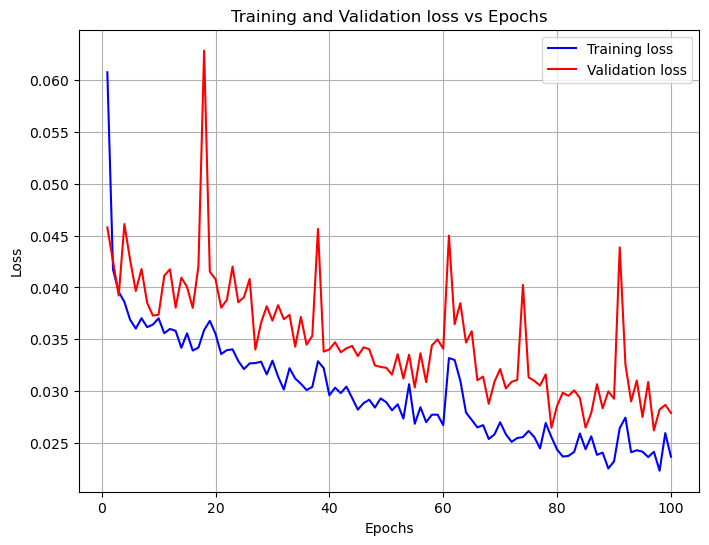

In [42]:
#Visualizing the model performance
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.plot(range(1,len(train_losses)+1),train_losses,label="Training loss",color="Blue")
plt.plot(range(1,len(val_losses)+1),val_losses,label="Validation loss",color="Red")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation loss vs Epochs")
plt.legend()
plt.grid()
plt.show()

## Estimating the performance of the model

## Debugging the model

In [ ]:
batch = next(iter(train_loader)).to(device)
out = model(batch)

print(out[:10])

In [ ]:
#Checking the gradients
loss.backward()

for name, param in model.named_parameters():
    if param.grad is not None:
        print(name, param.grad.abs().mean())

In [ ]:
for g in graphs[:1]:
    ei = g.edge_index

    for k in range(20):
        i = int(ei[0,k])
        j = int(ei[1,k])
        print(i, j, truth[i], truth[j])

In [ ]:
reco_to_sim = associations[0]["CLUE3DHigh_recoToSim_CP"]

for i in range(10):
    print(i, reco_to_sim[i])

In [ ]:
for ev in range(5):
    reco_to_sim = associations[ev]["CLUE3DHigh_recoToSim_CP"]
    unique = set([m[0] for m in reco_to_sim if len(m)>0])
    print("Event", ev, "particles:", unique)